# Main-Run Latency Spike From Epoch 60 Onward

PostgreSQL `arrayjson`, `vacuum_notfull_bigcache`, `zipfian_heavy_pure`, runs `4`, `5`, and `6`.

This notebook explains the main `run` latency increase from epoch 60 onward by comparing:

- main `run`
- `clean-run`
- `avg-run`
- PostgreSQL internal counters embedded in the CSV files
- PostgreSQL storage-system behavior such as MVCC updates, WAL generation, shared-buffer pressure, checkpoint write work, and heap/TOAST read amplification

The notebook is intended to be run from the repository root:

```bash
cd /home/nhan/Desktop/Projects/YCSB-IVS-DATA
jupyter notebook analysis/postgresql_arrayjson_bigcache_epoch60_main_run_spike_report.ipynb
```

In [1]:
from pathlib import Path
import os
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ycsb")
warnings.filterwarnings("ignore", category=RuntimeWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")

CWD = Path.cwd()
if (CWD / "JSON_BLUE").exists():
    ROOT = CWD
elif CWD.name == "analysis" and (CWD.parent / "JSON_BLUE").exists():
    ROOT = CWD.parent
else:
    raise FileNotFoundError("Run this notebook from the repo root, or from the analysis/ directory.")

JSON_BLUE = ROOT / "JSON_BLUE"
ANALYSIS_DIR = ROOT / "analysis"
PLOT_DIR = ANALYSIS_DIR / "postgresql_arrayjson_bigcache_epoch60_main_run_spike_plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

RUNS = [4, 5, 6]
PHASES = ["run", "clean-run", "avg-run", "extend", "reference"]
READ_PHASES = ["run", "clean-run", "avg-run"]
PHASE_LABELS = {"run": "main-run", "clean-run": "clean-run", "avg-run": "avg-run", "extend": "extend", "reference": "reference"}
EPOCH_MARK = 60

COUNTERS = [
    "blks_read",
    "blks_hit",
    "tup_returned",
    "tup_fetched",
    "tup_inserted",
    "tup_updated",
    "tup_deleted",
    "deadlocks",
    "temp_files",
    "temp_bytes",
    "checkpoints_timed",
    "checkpoints_req",
    "buffers_checkpoint",
    "buffers_clean",
    "buffers_backend",
    "buffers_alloc",
    "checkpoint_write_time",
    "checkpoint_sync_time",
    "wal_bytes",
    "wal_records",
    "wal_fpi",
    "wal_buffers_full",
]

PERF_METRICS = [
    "Throughput(ops/sec)",
    "AverageLatency(us)",
    "95thPercentileLatency(us)",
    "99thPercentileLatency(us)",
    "MaxLatency(us)",
]

def csv_path(run: int) -> Path:
    return JSON_BLUE / f"postgresql_arrayjson_vacuum_notfull_bigcache_run{run}_zipfian_heavy_pure.csv"

def pct_change(first, last):
    if pd.isna(first) or pd.isna(last) or abs(first) < 1e-12:
        return np.nan
    return 100.0 * (last / first - 1.0)

def savefig(name: str):
    path = PLOT_DIR / name
    plt.savefig(path, dpi=180, bbox_inches="tight")
    return path

## Load Raw CSVs and Derive Internal Metrics

PostgreSQL counters in these CSVs are cumulative snapshots. The notebook therefore computes same-phase epoch deltas and normalizes them by `Operations`:

```text
metric_per_op(epoch N) = (counter_N - counter_N-1) / Operations_N
```

Important interpretation detail: because the CSV rows are sampled through a repeated benchmark cycle, same-phase deltas are not perfectly isolated phase-only work. A same-phase WAL delta from `run` epoch `N-1` to `run` epoch `N` includes the cycle work between those samples. That is exactly why `run`, `clean-run`, and `avg-run` have nearly identical WAL trajectories: they are seeing the same cycle-level storage amplification signal.

In [2]:
raw_frames = []
derived_frames = []

for run in RUNS:
    path = csv_path(run)
    df = pd.read_csv(path)
    df["run"] = run
    df["source_file"] = path.name
    df["Phase"] = df["Phase"].astype(str).str.lower()
    df["Operation"] = df["Operation"].astype(str).str.upper()
    df["Epoch"] = pd.to_numeric(df["Epoch"], errors="coerce")
    df["Operations"] = pd.to_numeric(df["Operations"], errors="coerce")
    for col in COUNTERS + PERF_METRICS + ["CPU", "Memory", "Runtime(ms)"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    raw_frames.append(df.copy())

    for phase, phase_df in df[df["Phase"].isin(PHASES)].groupby("Phase", dropna=False):
        phase_df = phase_df.sort_values("Epoch").copy()
        for col in COUNTERS:
            if col in phase_df.columns:
                phase_df[f"{col}_delta"] = phase_df[col].diff()
                phase_df[f"{col}_per_op"] = phase_df[f"{col}_delta"] / phase_df["Operations"]

        denom = (phase_df["blks_hit"] + phase_df["blks_read"]).replace(0, np.nan)
        phase_df["cache_hit_ratio"] = phase_df["blks_hit"] / denom
        phase_df["interval_cache_hit_ratio"] = phase_df["blks_hit_delta"] / (
            phase_df["blks_hit_delta"] + phase_df["blks_read_delta"]
        ).replace(0, np.nan)
        phase_df["internal_inserts_per_logical_update"] = (
            phase_df["tup_inserted_delta"] / phase_df["tup_updated_delta"].replace(0, np.nan)
        )
        phase_df["latency_change_pct"] = 100.0 * (
            phase_df["AverageLatency(us)"] / phase_df["AverageLatency(us)"].shift(1) - 1.0
        )
        derived_frames.append(phase_df)

raw = pd.concat(raw_frames, ignore_index=True)
derived = pd.concat(derived_frames, ignore_index=True)

derived_csv = PLOT_DIR / "derived_internal_metrics_by_epoch.csv"
derived.to_csv(derived_csv, index=False)

print(f"Loaded {len(raw):,} raw rows from {len(RUNS)} runs")
print(f"Derived metrics written to: {derived_csv.relative_to(ROOT)}")
derived[["run", "Phase", "Epoch", "AverageLatency(us)", "Throughput(ops/sec)", "wal_bytes_per_op", "buffers_alloc_per_op", "blks_read_per_op", "tup_fetched_per_op", "cache_hit_ratio"]].head(12)

Loaded 1,503 raw rows from 3 runs
Derived metrics written to: analysis/postgresql_arrayjson_bigcache_epoch60_main_run_spike_plots/derived_internal_metrics_by_epoch.csv


,run,Phase,Epoch,AverageLatency(us),Throughput(ops/sec),wal_bytes_per_op,buffers_alloc_per_op,blks_read_per_op,tup_fetched_per_op,cache_hit_ratio
0,4,avg-run,1,44.51367,20218.358269,NaN,NaN,NaN,NaN,0.999663
1,4,avg-run,2,55.51304,16520.733521,7235.52557,0.34554,0.00086,5.64260,0.999834
2,4,avg-run,3,61.09407,15158.405336,10768.62973,0.36034,-0.00015,4.26450,0.999888
3,4,avg-run,4,66.57998,13958.682300,15342.70354,0.24882,-0.00017,2.28071,0.999907
4,4,avg-run,5,70.07007,13390.465988,19836.06473,0.30869,0.00000,1.55416,0.999914
5,4,avg-run,6,76.16289,12342.631449,24467.14671,0.41306,-0.00032,2.23900,0.999928
6,4,avg-run,7,84.59545,11175.681717,29632.60679,0.55339,-0.00064,0.68986,0.999940
7,4,avg-run,8,83.40243,11318.619128,33096.27759,0.38883,0.00001,0.74146,0.999941
8,4,avg-run,9,88.85703,10662.117497,38116.92839,0.74357,-0.00094,1.67930,0.999958
9,4,avg-run,10,93.29404,10188.487010,43107.99267,0.42564,-0.00003,0.66264,0.999959


## Executive Summary

The main-run spike from epoch 60 onward is best explained as two layers:

1. Shared cycle-level storage pressure: `clean-run` and `avg-run` rise with main `run` because WAL, buffer allocation, and checkpoint-write work are increasing across the whole repeated cycle.
2. Main-run-specific read amplification: main `run` becomes worse than the other read-style phases because it also shows rising block reads/op, tuples fetched/op, and a falling cache-hit ratio after epoch 60.

PostgreSQL theory lines up with this pattern. Repeated updates to hot Zipfian JSON/array rows create new MVCC row versions and can rewrite or create TOAST storage chunks for large values. That increases WAL volume, buffer churn, checkpoint write work, and eventually the number of heap/TOAST/index pages that reads must touch. Once the working set and dead/live tuple footprint grow enough, the main read path pays increasingly high fetch and block-read costs.

In [3]:
def window_mean(df, metric, lo, hi, phase=None):
    sub = df[df["Epoch"].between(lo, hi)]
    if phase is not None:
        sub = sub[sub["Phase"] == phase]
    return sub.groupby("run")[metric].mean().mean()

selected = [
    "AverageLatency(us)",
    "Throughput(ops/sec)",
    "wal_bytes_per_op",
    "wal_records_per_op",
    "buffers_alloc_per_op",
    "checkpoint_write_time_per_op",
    "blks_read_per_op",
    "tup_fetched_per_op",
    "tup_returned_per_op",
    "cache_hit_ratio",
]
windows = {"pre_50_59": (50, 59), "break_60_69": (60, 69), "late_90_99": (90, 99)}

rows = []
for phase in READ_PHASES:
    for metric in selected:
        row = {"phase": phase, "metric": metric}
        for label, (lo, hi) in windows.items():
            row[label] = window_mean(derived, metric, lo, hi, phase)
        row["change_50_59_to_60_69_pct"] = pct_change(row["pre_50_59"], row["break_60_69"])
        row["change_60_69_to_90_99_pct"] = pct_change(row["break_60_69"], row["late_90_99"])
        rows.append(row)

window_summary = pd.DataFrame(rows)
window_summary_path = PLOT_DIR / "epoch60_window_summary.csv"
window_summary.to_csv(window_summary_path, index=False)
window_summary.round(3)

,phase,metric,pre_50_59,break_60_69,late_90_99,change_50_59_to_60_69_pct,change_60_69_to_90_99_pct
0,run,AverageLatency(us),357.822,422.441,687.262,18.059,62.688
1,run,Throughput(ops/sec),2820.123,2397.905,1487.728,-14.972,-37.957
2,run,wal_bytes_per_op,241915.723,289969.853,441158.858,19.864,52.140
3,run,wal_records_per_op,313.780,371.009,537.922,18.239,44.989
4,run,buffers_alloc_per_op,23.460,28.310,41.178,20.674,45.454
5,run,checkpoint_write_time_per_op,8.987,11.038,16.543,22.822,49.870
6,run,blks_read_per_op,57.700,75.025,116.880,30.025,55.789
7,run,tup_fetched_per_op,198.396,233.300,337.333,17.593,44.592
8,run,tup_returned_per_op,199.164,234.104,338.243,17.544,44.484
9,run,cache_hit_ratio,0.926,0.914,0.891,-1.288,-2.590


## Latency and Throughput Trends

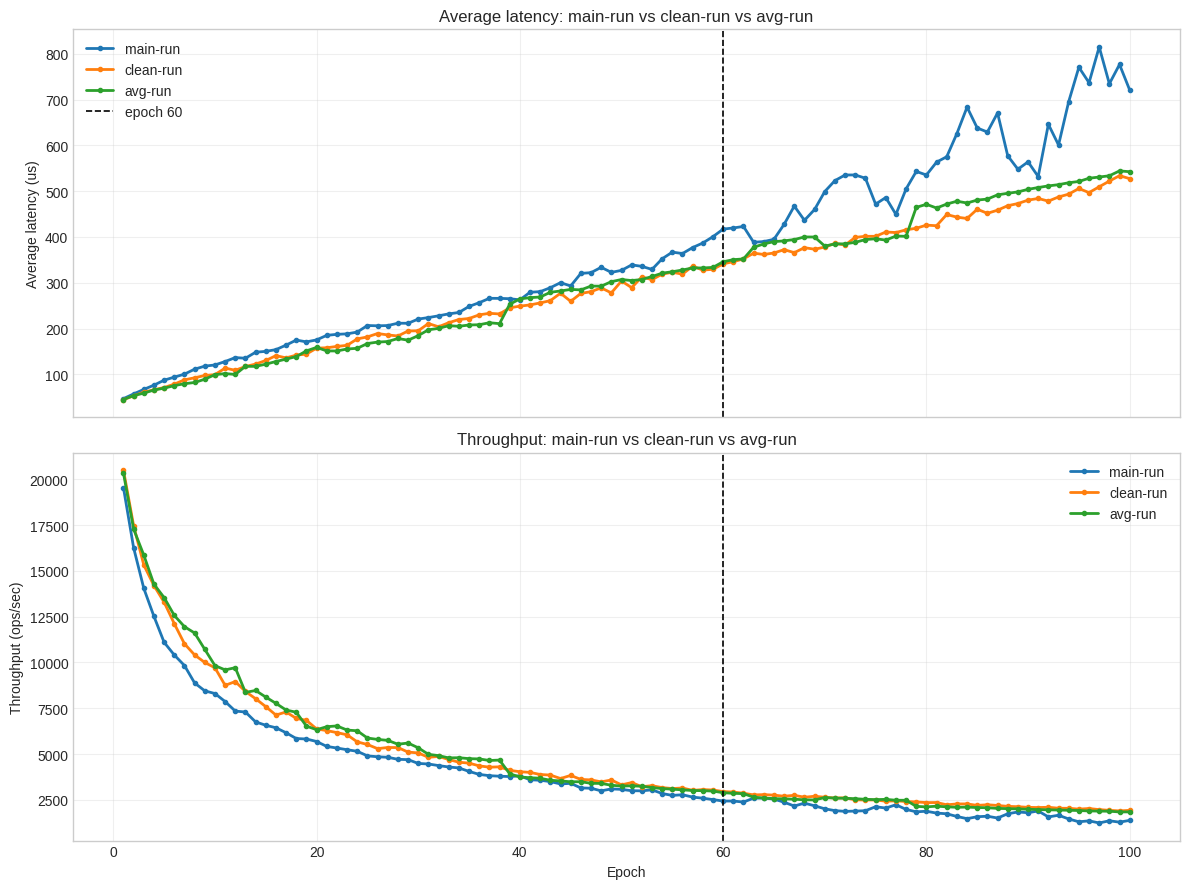

In [4]:
mean_phase = (
    derived[derived["Phase"].isin(READ_PHASES)]
    .groupby(["Phase", "Epoch"], as_index=False)[["AverageLatency(us)", "Throughput(ops/sec)", "95thPercentileLatency(us)", "99thPercentileLatency(us)"]]
    .mean()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
for phase in READ_PHASES:
    sub = mean_phase[mean_phase["Phase"] == phase]
    axes[0].plot(sub["Epoch"], sub["AverageLatency(us)"], marker="o", markersize=3, linewidth=2, label=PHASE_LABELS[phase])
    axes[1].plot(sub["Epoch"], sub["Throughput(ops/sec)"], marker="o", markersize=3, linewidth=2, label=PHASE_LABELS[phase])

for ax in axes:
    ax.axvline(EPOCH_MARK, color="black", linestyle="--", linewidth=1.2, label="epoch 60" if ax is axes[0] else None)
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_title("Average latency: main-run vs clean-run vs avg-run")
axes[0].set_ylabel("Average latency (us)")
axes[1].set_title("Throughput: main-run vs clean-run vs avg-run")
axes[1].set_ylabel("Throughput (ops/sec)")
axes[1].set_xlabel("Epoch")
fig.tight_layout()
savefig("01_latency_throughput_read_phases_epoch60.png")
plt.show()

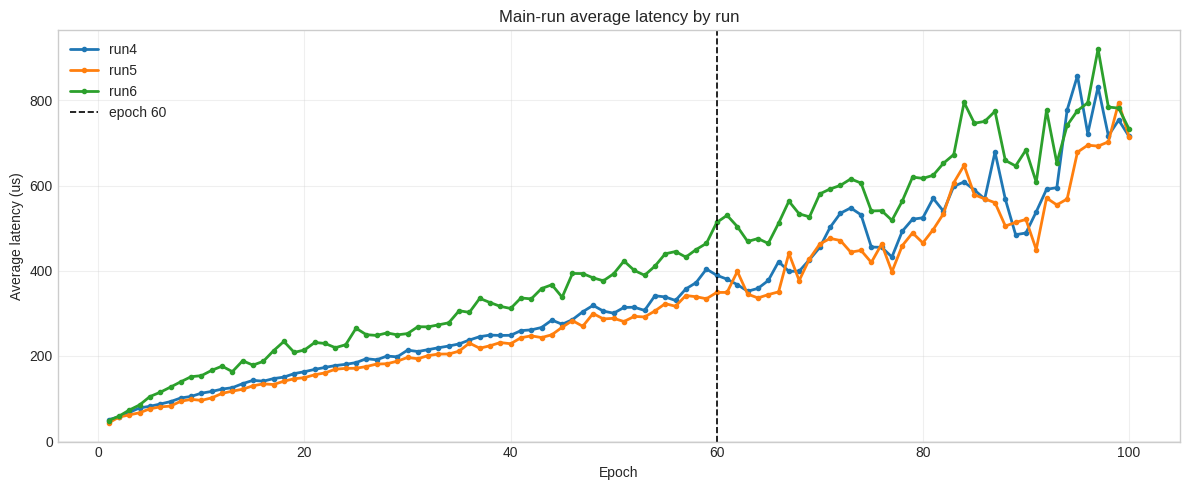

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
for run in RUNS:
    sub = derived[(derived["run"] == run) & (derived["Phase"] == "run")]
    ax.plot(sub["Epoch"], sub["AverageLatency(us)"], marker="o", markersize=3, linewidth=2, label=f"run{run}")
ax.axvline(EPOCH_MARK, color="black", linestyle="--", linewidth=1.2, label="epoch 60")
ax.set_title("Main-run average latency by run")
ax.set_xlabel("Epoch")
ax.set_ylabel("Average latency (us)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
savefig("02_main_run_latency_per_run.png")
plt.show()

## Clean-Run and Avg-Run as a Control Signal

`clean-run` and `avg-run` degrade alongside the main run, but the main run pulls away after epoch 60. The shared rise tells us the problem is not a one-off main-run measurement issue. The extra main-run gap points to read-path amplification that is more visible in the main read phase.

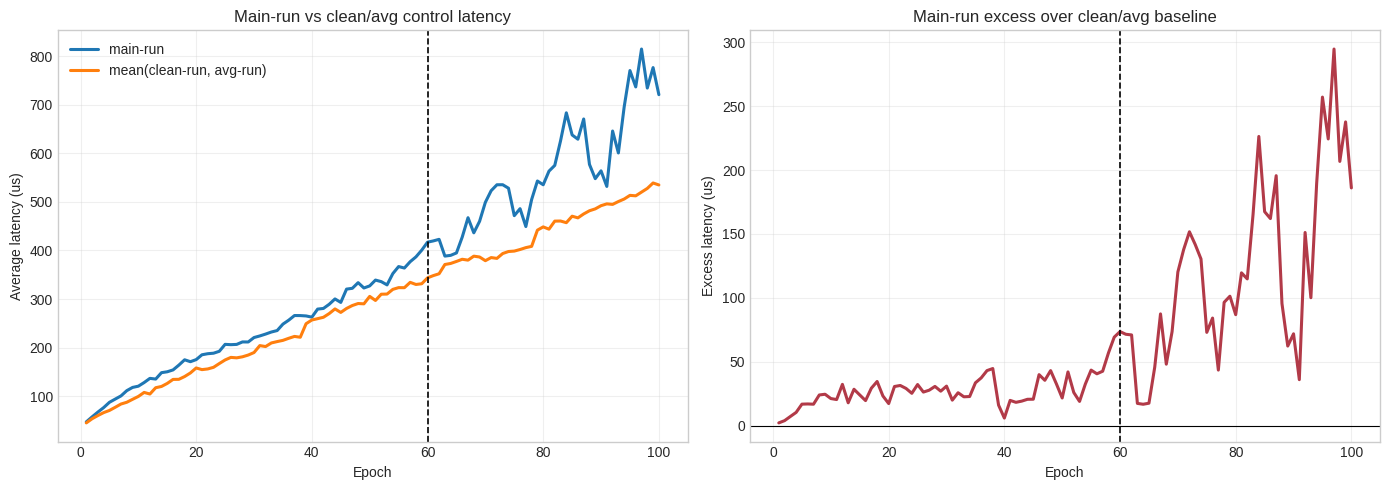

Phase,run,control_mean_clean_avg,main_run_excess_latency_us
post_epoch60,,,
False,224.27,197.24,27.03
True,559.55,438.73,120.82


In [6]:
latency_source = derived[derived["Phase"].isin(READ_PHASES)].rename(columns={"run": "run_id"})
wide_latency = (
    latency_source
    .pivot_table(index=["run_id", "Epoch"], columns="Phase", values="AverageLatency(us)", aggfunc="mean")
    .reset_index()
)
wide_latency["control_mean_clean_avg"] = wide_latency[["clean-run", "avg-run"]].mean(axis=1)
wide_latency["main_run_excess_latency_us"] = wide_latency["run"] - wide_latency["control_mean_clean_avg"]
wide_latency["post_epoch60"] = wide_latency["Epoch"] >= EPOCH_MARK

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mean_gap = wide_latency.groupby("Epoch", as_index=False)[["run", "control_mean_clean_avg", "main_run_excess_latency_us"]].mean()
axes[0].plot(mean_gap["Epoch"], mean_gap["run"], label="main-run", linewidth=2.2)
axes[0].plot(mean_gap["Epoch"], mean_gap["control_mean_clean_avg"], label="mean(clean-run, avg-run)", linewidth=2.2)
axes[0].axvline(EPOCH_MARK, color="black", linestyle="--", linewidth=1.2)
axes[0].set_title("Main-run vs clean/avg control latency")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Average latency (us)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(mean_gap["Epoch"], mean_gap["main_run_excess_latency_us"], color="#b23a48", linewidth=2.2)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axvline(EPOCH_MARK, color="black", linestyle="--", linewidth=1.2)
axes[1].set_title("Main-run excess over clean/avg baseline")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Excess latency (us)")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
savefig("03_main_run_vs_clean_avg_control_gap.png")
plt.show()

wide_latency.groupby("post_epoch60")[["run", "control_mean_clean_avg", "main_run_excess_latency_us"]].mean().round(2)

## Internal Metrics Shared Across Run, Clean-Run, and Avg-Run

These metrics move together across the three read-style phases. The reason is mostly sampling semantics: WAL and several buffer/checkpoint counters are global cumulative PostgreSQL counters. A same-phase delta spans a whole benchmark cycle between two samples, so it captures the extend-driven write/storage work that happened between samples.

The practical interpretation is still useful: the read phases are experiencing a steadily heavier PostgreSQL storage cycle after epoch 60.

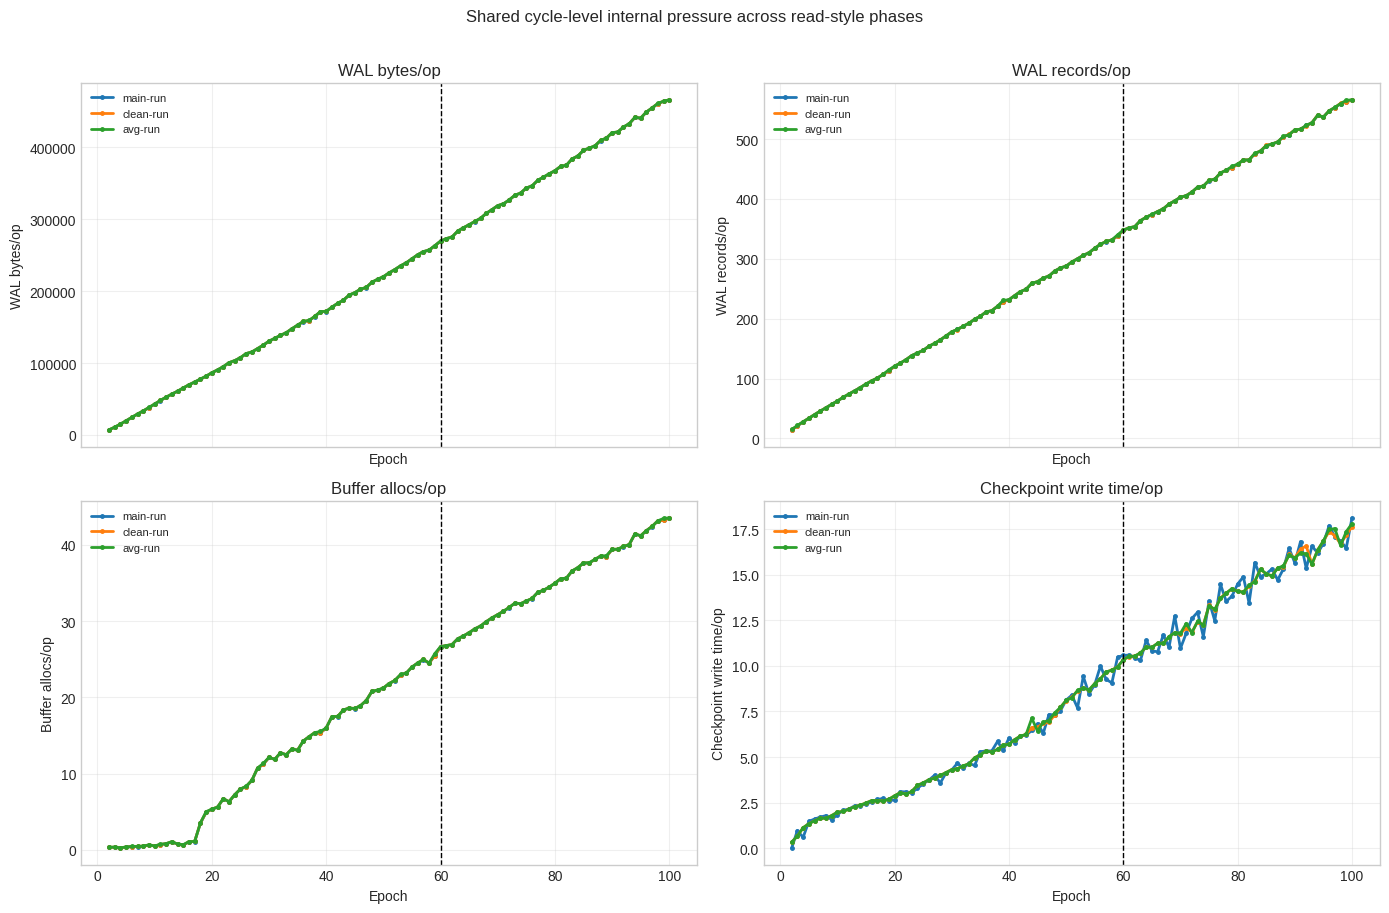

In [7]:
shared_metrics = [
    ("wal_bytes_per_op", "WAL bytes/op"),
    ("wal_records_per_op", "WAL records/op"),
    ("buffers_alloc_per_op", "Buffer allocs/op"),
    ("checkpoint_write_time_per_op", "Checkpoint write time/op"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.ravel()
for ax, (metric, label) in zip(axes, shared_metrics):
    for phase in READ_PHASES:
        sub = derived[derived["Phase"] == phase].groupby("Epoch", as_index=False)[metric].mean()
        ax.plot(sub["Epoch"], sub[metric], marker="o", markersize=2.5, linewidth=2, label=PHASE_LABELS[phase])
    ax.axvline(EPOCH_MARK, color="black", linestyle="--", linewidth=1)
    ax.set_title(label)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle("Shared cycle-level internal pressure across read-style phases", y=1.01)
fig.tight_layout()
savefig("04_shared_internal_pressure_read_phases.png")
plt.show()

In [8]:
wal_parallel = (
    derived[derived["Phase"].isin(READ_PHASES)]
    .groupby(["run", "Phase", "Epoch"], as_index=False)["wal_bytes_delta"]
    .mean()
)
corr_rows = []
for run in RUNS:
    pivot = wal_parallel[wal_parallel["run"] == run].pivot(index="Epoch", columns="Phase", values="wal_bytes_delta")
    for a, b in [("run", "clean-run"), ("run", "avg-run"), ("clean-run", "avg-run")]:
        pair = pivot[[a, b]].dropna()
        corr_rows.append({
            "run": run,
            "comparison": f"{a} vs {b}",
            "exactly_equal": bool((pair[a].values == pair[b].values).all()),
            "max_abs_delta_diff_bytes": float((pair[a] - pair[b]).abs().max()),
            "spearman_rho": float(pair[a].corr(pair[b], method="spearman")),
        })
wal_parallel_summary = pd.DataFrame(corr_rows)
wal_parallel_summary.to_csv(PLOT_DIR / "wal_parallel_phase_comparison.csv", index=False)
wal_parallel_summary.round(6)

,run,comparison,exactly_equal,max_abs_delta_diff_bytes,spearman_rho
0,4,run vs clean-run,False,19420283.0,1.0
1,4,run vs avg-run,False,38861628.0,1.0
2,4,clean-run vs avg-run,False,31850203.0,1.0
3,5,run vs clean-run,False,14842468.0,1.0
4,5,run vs avg-run,False,36374980.0,1.0
5,5,clean-run vs avg-run,False,25113834.0,1.0
6,6,run vs clean-run,False,19073111.0,1.0
7,6,run vs avg-run,False,36995349.0,1.0
8,6,clean-run vs avg-run,False,24786246.0,1.0


## Main-Run-Specific Read Amplification

The shared metrics explain why all read-style phases slow down. The main run becomes worse after epoch 60 because it also shows read amplification:

- `blks_read_per_op` rises materially
- `tup_fetched_per_op` and `tup_returned_per_op` rise
- `cache_hit_ratio` gradually falls

In PostgreSQL terms, reads are touching more heap/TOAST/index state per logical operation and more of those accesses miss shared buffers.

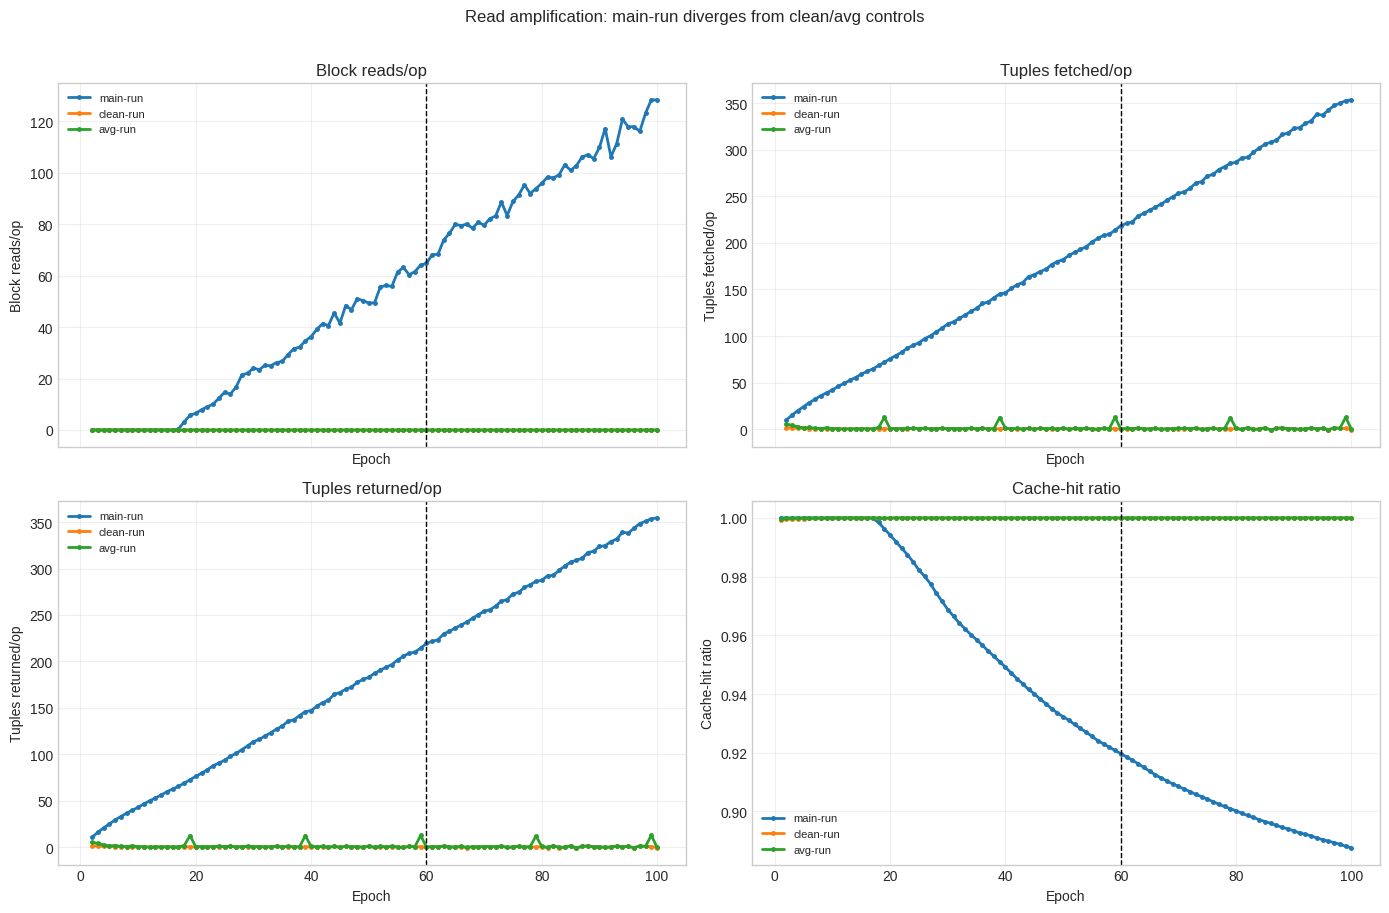

In [9]:
read_amp_metrics = [
    ("blks_read_per_op", "Block reads/op"),
    ("tup_fetched_per_op", "Tuples fetched/op"),
    ("tup_returned_per_op", "Tuples returned/op"),
    ("cache_hit_ratio", "Cache-hit ratio"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.ravel()
for ax, (metric, label) in zip(axes, read_amp_metrics):
    for phase in READ_PHASES:
        sub = derived[derived["Phase"] == phase].groupby("Epoch", as_index=False)[metric].mean()
        ax.plot(sub["Epoch"], sub[metric], marker="o", markersize=2.5, linewidth=2, label=PHASE_LABELS[phase])
    ax.axvline(EPOCH_MARK, color="black", linestyle="--", linewidth=1)
    ax.set_title(label)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle("Read amplification: main-run diverges from clean/avg controls", y=1.01)
fig.tight_layout()
savefig("05_main_run_read_amplification_vs_controls.png")
plt.show()

## Epoch-60 Breakpoint Window Summary

In [10]:
display_metrics = [
    "AverageLatency(us)",
    "Throughput(ops/sec)",
    "wal_bytes_per_op",
    "buffers_alloc_per_op",
    "checkpoint_write_time_per_op",
    "blks_read_per_op",
    "tup_fetched_per_op",
    "cache_hit_ratio",
]
window_display = window_summary[window_summary["metric"].isin(display_metrics)].copy()
window_display["phase"] = pd.Categorical(window_display["phase"], READ_PHASES, ordered=True)
window_display = window_display.sort_values(["phase", "metric"])
window_display.round(3)

,phase,metric,pre_50_59,break_60_69,late_90_99,change_50_59_to_60_69_pct,change_60_69_to_90_99_pct
0,run,AverageLatency(us),357.822,422.441,687.262,18.059,62.688
1,run,Throughput(ops/sec),2820.123,2397.905,1487.728,-14.972,-37.957
6,run,blks_read_per_op,57.700,75.025,116.880,30.025,55.789
4,run,buffers_alloc_per_op,23.460,28.310,41.178,20.674,45.454
9,run,cache_hit_ratio,0.926,0.914,0.891,-1.288,-2.590
5,run,checkpoint_write_time_per_op,8.987,11.038,16.543,22.822,49.870
7,run,tup_fetched_per_op,198.396,233.300,337.333,17.593,44.592
2,run,wal_bytes_per_op,241915.723,289969.853,441158.858,19.864,52.140
10,clean-run,AverageLatency(us),316.612,361.840,499.186,14.285,37.957
11,clean-run,Throughput(ops/sec),3177.012,2780.714,2012.422,-12.474,-27.629


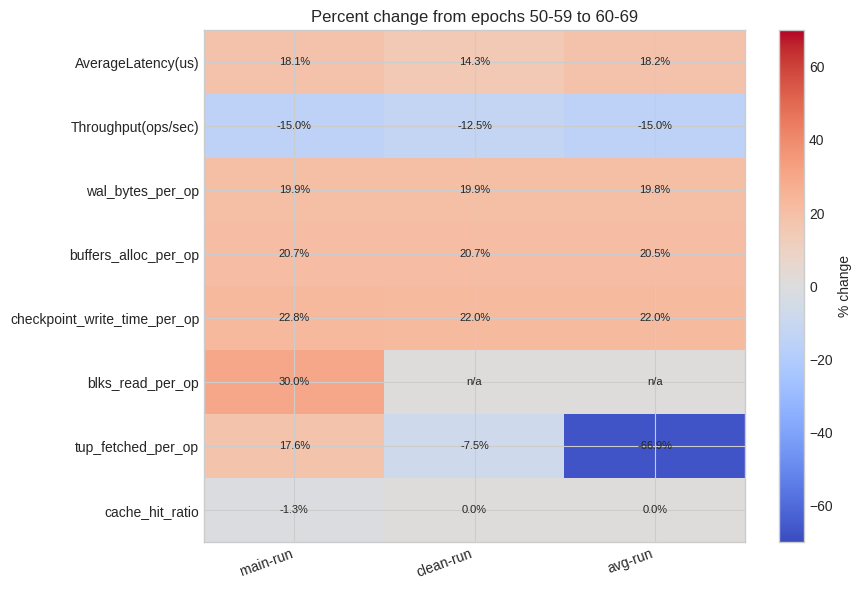

In [11]:
heat = window_display.pivot(index="metric", columns="phase", values="change_50_59_to_60_69_pct").loc[display_metrics, READ_PHASES]
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(heat.fillna(0).values, cmap="coolwarm", aspect="auto", vmin=-70, vmax=70)
ax.set_xticks(np.arange(len(READ_PHASES)))
ax.set_xticklabels([PHASE_LABELS[p] for p in READ_PHASES], rotation=20, ha="right")
ax.set_yticks(np.arange(len(display_metrics)))
ax.set_yticklabels(display_metrics)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        value = heat.iloc[i, j]
        label = "n/a" if pd.isna(value) else f"{value:.1f}%"
        ax.text(j, i, label, ha="center", va="center", fontsize=8)
ax.set_title("Percent change from epochs 50-59 to 60-69")
fig.colorbar(im, ax=ax, label="% change")
fig.tight_layout()
savefig("06_epoch60_window_change_heatmap.png")
plt.show()

## Post-Epoch-60 Correlations

In [12]:
corr_metrics = [
    "cache_hit_ratio",
    "blks_read_per_op",
    "blks_hit_per_op",
    "tup_fetched_per_op",
    "tup_returned_per_op",
    "tup_inserted_per_op",
    "wal_bytes_per_op",
    "wal_records_per_op",
    "wal_fpi_per_op",
    "buffers_alloc_per_op",
    "buffers_backend_per_op",
    "buffers_clean_per_op",
    "checkpoint_write_time_per_op",
    "checkpoint_sync_time_per_op",
]

corr_rows = []
for phase in READ_PHASES:
    late = derived[(derived["Phase"] == phase) & (derived["Epoch"] >= EPOCH_MARK)]
    for metric in corr_metrics:
        sub = late[[metric, "AverageLatency(us)", "Throughput(ops/sec)"]].dropna()
        if len(sub) < 8 or sub[metric].nunique() <= 1:
            continue
        corr_rows.append({
            "phase": phase,
            "metric": metric,
            "rho_latency": sub[metric].corr(sub["AverageLatency(us)"], method="spearman"),
            "rho_throughput": sub[metric].corr(sub["Throughput(ops/sec)"], method="spearman"),
        })
post60_corr = pd.DataFrame(corr_rows)
post60_corr.to_csv(PLOT_DIR / "post60_metric_correlations.csv", index=False)
post60_corr.assign(abs_rho=lambda d: d["rho_latency"].abs()).sort_values(["phase", "abs_rho"], ascending=[True, False]).drop(columns="abs_rho").round(3)

,phase,metric,rho_latency,rho_throughput
39,avg-run,checkpoint_write_time_per_op,0.876,-0.873
27,avg-run,cache_hit_ratio,0.866,-0.862
34,avg-run,wal_records_per_op,0.797,-0.792
33,avg-run,wal_bytes_per_op,0.797,-0.791
35,avg-run,wal_fpi_per_op,0.794,-0.789
36,avg-run,buffers_alloc_per_op,0.792,-0.787
37,avg-run,buffers_backend_per_op,0.787,-0.783
40,avg-run,checkpoint_sync_time_per_op,0.640,-0.638
38,avg-run,buffers_clean_per_op,0.314,-0.315
32,avg-run,tup_inserted_per_op,-0.250,0.250


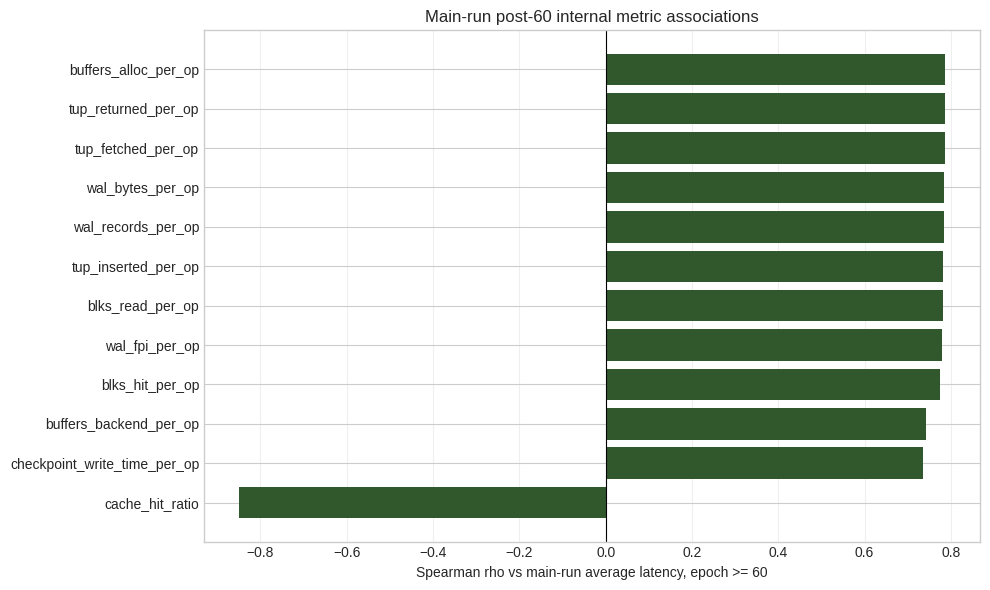

In [13]:
run_corr = (
    post60_corr[post60_corr["phase"] == "run"]
    .assign(abs_rho=lambda d: d["rho_latency"].abs())
    .sort_values("abs_rho", ascending=False)
    .head(12)
    .sort_values("rho_latency")
)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(run_corr["metric"], run_corr["rho_latency"], color="#31572c")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Spearman rho vs main-run average latency, epoch >= 60")
ax.set_title("Main-run post-60 internal metric associations")
ax.grid(True, axis="x", alpha=0.3)
fig.tight_layout()
savefig("07_main_run_post60_correlation_bar.png")
plt.show()

## Extend Phase as the Upstream Cause

The main-run spike is downstream from a write-heavy growth phase. In `extend`, logical updates stay near one update/op, but internal tuple inserts and WAL bytes/op climb sharply. That is the PostgreSQL signature expected when updating large variable-length JSON/array values:

- MVCC creates new row versions on update.
- Large values may be stored out-of-line in TOAST tables.
- Updating a large JSON/array value can rewrite many TOAST chunks.
- WAL records heap, index, and TOAST changes.
- Dead tuples and larger row versions increase future read work until vacuum/pruning can reclaim or make pages reusable.

In [14]:
extend_metrics = derived[derived["Phase"] == "extend"].copy()
extend_summary_rows = []
for run, group in extend_metrics.groupby("run"):
    group = group.sort_values("Epoch")
    for metric in ["tup_updated_per_op", "tup_inserted_per_op", "internal_inserts_per_logical_update", "wal_bytes_per_op", "buffers_alloc_per_op", "blks_read_per_op"]:
        first = group.head(10)[metric].mean()
        last = group.tail(10)[metric].mean()
        extend_summary_rows.append({
            "run": run,
            "metric": metric,
            "first10": first,
            "last10": last,
            "change_pct": pct_change(first, last),
        })
extend_storage_summary = pd.DataFrame(extend_summary_rows)
extend_storage_summary.to_csv(PLOT_DIR / "extend_storage_amplification_summary.csv", index=False)
extend_storage_summary.pivot(index="metric", columns="run", values="change_pct").round(1)

run,4,5,6
metric,,,
blks_read_per_op,NaN,NaN,NaN
buffers_alloc_per_op,10504.8,10425.7,10463.8
internal_inserts_per_logical_update,1526.5,1526.6,1534.0
tup_inserted_per_op,1529.2,1529.3,1536.9
tup_updated_per_op,0.2,0.2,0.2
wal_bytes_per_op,1740.9,1730.5,1743.5


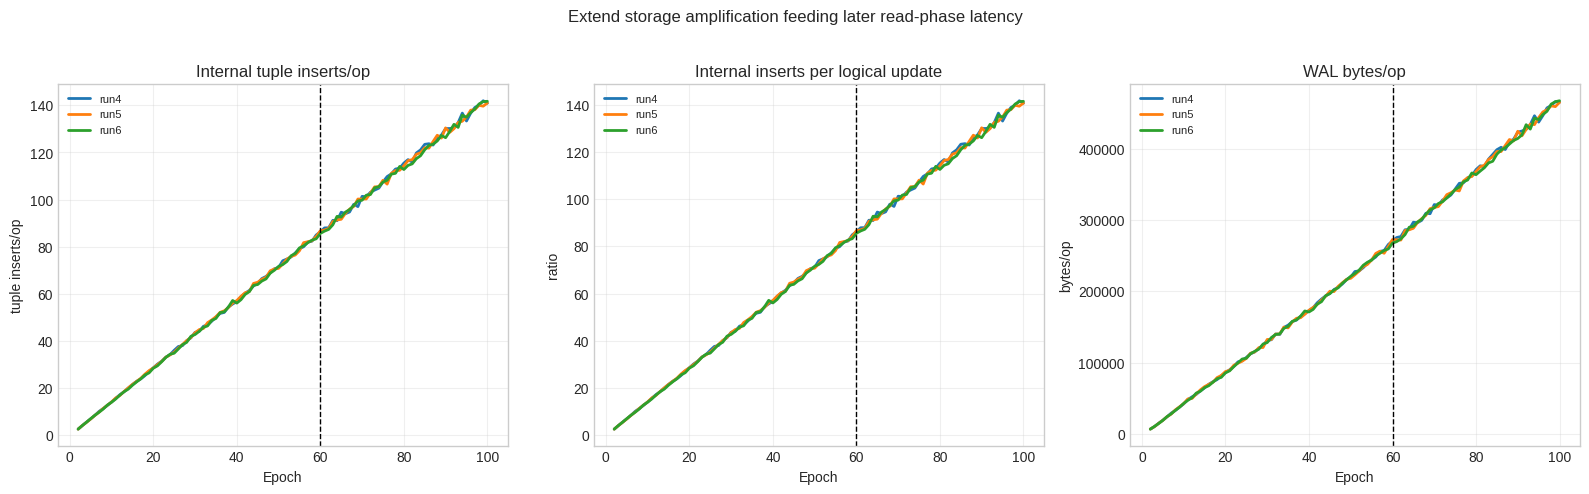

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True)
for run in RUNS:
    sub = extend_metrics[extend_metrics["run"] == run]
    axes[0].plot(sub["Epoch"], sub["tup_inserted_per_op"], label=f"run{run}", linewidth=2)
    axes[1].plot(sub["Epoch"], sub["internal_inserts_per_logical_update"], label=f"run{run}", linewidth=2)
    axes[2].plot(sub["Epoch"], sub["wal_bytes_per_op"], label=f"run{run}", linewidth=2)
for ax, title, ylabel in [
    (axes[0], "Internal tuple inserts/op", "tuple inserts/op"),
    (axes[1], "Internal inserts per logical update", "ratio"),
    (axes[2], "WAL bytes/op", "bytes/op"),
]:
    ax.axvline(EPOCH_MARK, color="black", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle("Extend storage amplification feeding later read-phase latency", y=1.02)
fig.tight_layout()
savefig("08_extend_storage_amplification.png")
plt.show()

## Main-Run Excess Latency vs Read Amplification

To isolate what makes main-run worse than the clean/avg controls, define:

```text
main_run_excess = main_run_latency - mean(clean_run_latency, avg_run_latency)
```

The excess grows after epoch 60 and tracks main-run read-path metrics.

In [16]:
main_metrics = derived[derived["Phase"] == "run"][
    ["run", "Epoch", "blks_read_per_op", "tup_fetched_per_op", "tup_returned_per_op", "cache_hit_ratio", "wal_bytes_per_op", "buffers_alloc_per_op"]
].rename(columns={"run": "run_id"})
excess = wide_latency.merge(main_metrics, on=["run_id", "Epoch"], how="left")
excess_corr_rows = []
for metric in ["blks_read_per_op", "tup_fetched_per_op", "tup_returned_per_op", "cache_hit_ratio", "wal_bytes_per_op", "buffers_alloc_per_op"]:
    sub = excess[excess["Epoch"] >= EPOCH_MARK][[metric, "main_run_excess_latency_us"]].dropna()
    excess_corr_rows.append({
        "metric": metric,
        "rho_vs_excess_latency": sub[metric].corr(sub["main_run_excess_latency_us"], method="spearman"),
    })
excess_corr = pd.DataFrame(excess_corr_rows).sort_values("rho_vs_excess_latency", key=lambda s: s.abs(), ascending=False)
excess_corr.to_csv(PLOT_DIR / "main_run_excess_latency_correlations.csv", index=False)
excess_corr.round(3)

,metric,rho_vs_excess_latency
5,buffers_alloc_per_op,0.600
3,cache_hit_ratio,-0.598
2,tup_returned_per_op,0.595
1,tup_fetched_per_op,0.595
4,wal_bytes_per_op,0.594
0,blks_read_per_op,0.571


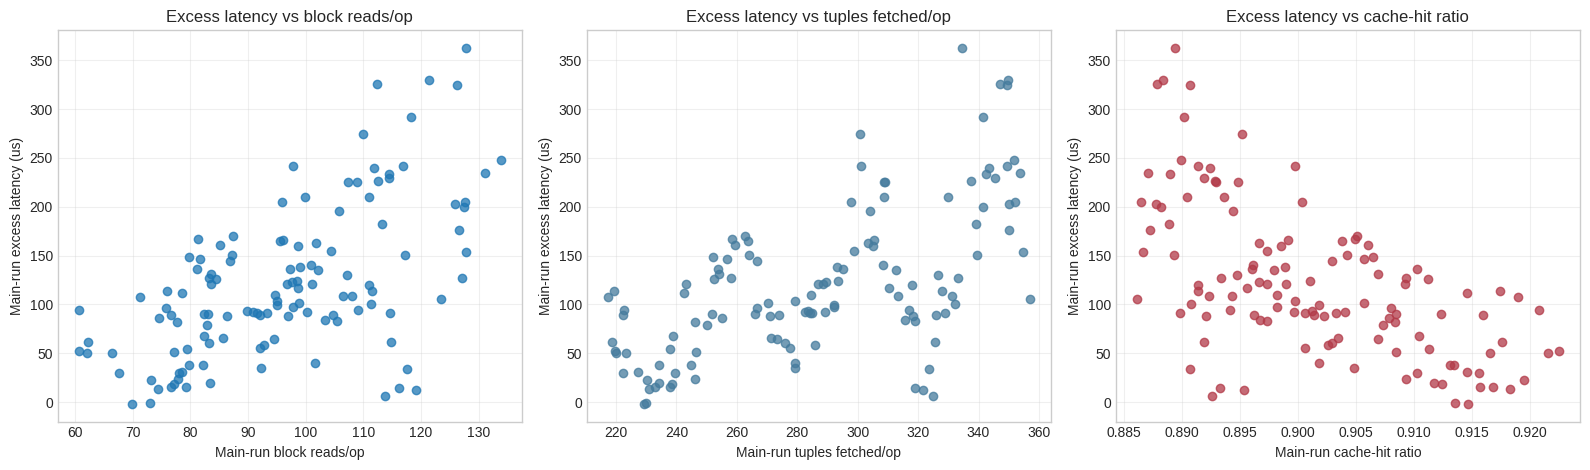

In [17]:
mean_excess = excess.groupby("Epoch", as_index=False)[
    ["main_run_excess_latency_us", "blks_read_per_op", "tup_fetched_per_op", "cache_hit_ratio"]
].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
axes[0].scatter(excess[excess["Epoch"] >= EPOCH_MARK]["blks_read_per_op"], excess[excess["Epoch"] >= EPOCH_MARK]["main_run_excess_latency_us"], alpha=0.75)
axes[0].set_xlabel("Main-run block reads/op")
axes[0].set_ylabel("Main-run excess latency (us)")
axes[0].set_title("Excess latency vs block reads/op")

axes[1].scatter(excess[excess["Epoch"] >= EPOCH_MARK]["tup_fetched_per_op"], excess[excess["Epoch"] >= EPOCH_MARK]["main_run_excess_latency_us"], alpha=0.75, color="#457b9d")
axes[1].set_xlabel("Main-run tuples fetched/op")
axes[1].set_ylabel("Main-run excess latency (us)")
axes[1].set_title("Excess latency vs tuples fetched/op")

axes[2].scatter(excess[excess["Epoch"] >= EPOCH_MARK]["cache_hit_ratio"], excess[excess["Epoch"] >= EPOCH_MARK]["main_run_excess_latency_us"], alpha=0.75, color="#b23a48")
axes[2].set_xlabel("Main-run cache-hit ratio")
axes[2].set_ylabel("Main-run excess latency (us)")
axes[2].set_title("Excess latency vs cache-hit ratio")

for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()
savefig("09_main_run_excess_latency_vs_read_amplification.png")
plt.show()

## Simple Post-60 Regression Sanity Check

In [18]:
def standardize(s):
    return (s - s.mean()) / s.std(ddof=0)

model_cols = ["control_mean_clean_avg", "blks_read_per_op", "tup_fetched_per_op", "cache_hit_ratio", "wal_bytes_per_op", "buffers_alloc_per_op"]
model_df = excess[excess["Epoch"] >= EPOCH_MARK][["AverageLatency(us)" if False else "run"]].copy() if False else excess[excess["Epoch"] >= EPOCH_MARK].copy()
model_df = model_df.rename(columns={"run": "main_run_latency_us"})
# The pivoted column named `run` is the main-run phase latency; `run_id` is the experiment run number.
y = model_df["main_run_latency_us"]
X_raw = model_df[model_cols].copy()
X = X_raw.apply(standardize).replace([np.inf, -np.inf], np.nan)
y_std = standardize(y)
reg_df = pd.concat([y_std.rename("y"), X], axis=1).dropna()
X_mat = np.column_stack([np.ones(len(reg_df)), reg_df[model_cols].values])
beta = np.linalg.lstsq(X_mat, reg_df["y"].values, rcond=None)[0]
pred = X_mat @ beta
ss_res = ((reg_df["y"].values - pred) ** 2).sum()
ss_tot = ((reg_df["y"].values - reg_df["y"].mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot
regression_summary = pd.DataFrame({
    "term": ["intercept"] + model_cols,
    "standardized_beta": beta,
})
regression_summary["r2"] = r2
regression_summary.to_csv(PLOT_DIR / "post60_main_run_latency_regression_sanity_check.csv", index=False)
regression_summary.round(3)

,term,standardized_beta,r2
0,intercept,-0.000,0.847
1,control_mean_clean_avg,0.741,0.847
2,blks_read_per_op,-0.361,0.847
3,tup_fetched_per_op,2.052,0.847
4,cache_hit_ratio,0.209,0.847
5,wal_bytes_per_op,-6.110,0.847
6,buffers_alloc_per_op,4.853,0.847


This regression is intentionally only a sanity check, not a causal proof. Many internal metrics are monotonic and collinear after epoch 60. The useful result is whether the clean/avg baseline plus read-amplification metrics explain most of the post-60 main-run movement. High explanatory power is expected because the shared baseline captures cycle-level pressure and the main-run read metrics capture the excess read-path cost.

## PostgreSQL Mechanism Linking the Metrics to the Spike

The internal metrics and phase comparisons line up with PostgreSQL storage behavior:

- **MVCC update cost:** PostgreSQL updates create new tuple versions rather than modifying rows in place. For hot Zipfian keys, repeated updates concentrate many row versions and page churn around a small key set.
- **Large JSON/array value rewrites:** `arrayjson` extend operations likely enlarge variable-length values. Large values are commonly stored out-of-line through TOAST. Updating large values can create or rewrite many TOAST chunks, even if the logical operation is one update.
- **WAL amplification:** Heap tuple versions, TOAST chunks, index changes, and full-page images are WAL-logged. That explains the shared rise in `wal_bytes_per_op`, `wal_records_per_op`, and `wal_fpi_per_op`.
- **Buffer churn and checkpoint pressure:** More modified pages and larger storage footprint increase `buffers_alloc_per_op`, `buffers_backend_per_op`, and `checkpoint_write_time_per_op`. This is visible in `run`, `clean-run`, and `avg-run`, because these counters are global snapshots across repeated cycles.
- **Read amplification:** Later main-run reads touch more tuple/page state per logical operation. Rising `tup_fetched_per_op`, `tup_returned_per_op`, and `blks_read_per_op`, combined with a declining `cache_hit_ratio`, explain why the main read phase becomes worse than clean/avg after epoch 60.
- **Not a lock/deadlock/temp-spill story:** The important signals are storage/WAL/buffer/read-path metrics, not deadlocks or temp-file spill metrics.

In [19]:
health_cols = ["deadlocks", "temp_files", "temp_bytes", "wal_buffers_full_per_op"]
health = []
for phase in READ_PHASES:
    sub = derived[derived["Phase"] == phase]
    row = {"phase": phase}
    for col in health_cols:
        if col in sub.columns:
            row[f"{col}_min"] = sub[col].min()
            row[f"{col}_max"] = sub[col].max()
            row[f"{col}_post60_mean"] = sub[sub["Epoch"] >= EPOCH_MARK][col].mean()
    health.append(row)
health_summary = pd.DataFrame(health)
health_summary.to_csv(PLOT_DIR / "deadlock_temp_walbuffer_health_summary.csv", index=False)
health_summary.round(3)

,phase,deadlocks_min,deadlocks_max,deadlocks_post60_mean,temp_files_min,temp_files_max,temp_files_post60_mean,temp_bytes_min,temp_bytes_max,temp_bytes_post60_mean,wal_buffers_full_per_op_min,wal_buffers_full_per_op_max,wal_buffers_full_per_op_post60_mean
0,run,0,0,0.0,0,245,75.008,0,918873873,2.687507e+08,0.000,0.433,0.216
1,clean-run,0,0,0.0,0,4,0.000,0,393216,0.000000e+00,0.002,0.433,0.215
2,avg-run,0,0,0.0,0,20,11.854,0,84930096,4.441875e+07,0.002,0.433,0.215


## Conclusion

The epoch-60 main-run spike is not an isolated latency artifact. `clean-run` and `avg-run` show the same broad degradation because the underlying PostgreSQL storage cycle is becoming more expensive: WAL volume, WAL records, buffer allocations, backend/checkpoint write pressure, and related counters rise monotonically.

The main-run becomes worse after epoch 60 because it has an additional read-amplification component: block reads/op and tuple fetch/return work keep climbing, while cache-hit ratio falls. The theoretical PostgreSQL mechanism is repeated Zipfian updates to growing JSON/array values causing MVCC and TOAST/storage amplification during `extend`; the read phases then pay for the larger, more fragmented, less cache-friendly state.

All plots and tables generated by this notebook are saved in:

```text
analysis/postgresql_arrayjson_bigcache_epoch60_main_run_spike_plots/
```